In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
!pip install xgboost
from xgboost import XGBClassifier


from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
TW = pd.read_csv(
    r"../classification/Twitter/Absolute_labeling/Twitter-Absolute-Sigma-500.data",
    sep=",",
    header=None
)

groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = []
for group in groups:
    for t in range(7):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TW.columns = columns

TW.head(2)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,AI_0,AI_1,AI_2,...,ADL_5,ADL_6,NAD_0,NAD_1,NAD_2,NAD_3,NAD_4,NAD_5,NAD_6,label
0,889,939,960,805,805,1143,1121,549,613,587,...,1.0,1.0,889,939,960,805,805,1143,1121,1.0
1,542,473,504,626,647,795,832,366,288,318,...,1.0,1.0,542,473,504,626,647,795,832,1.0


In [6]:
TH = pd.read_csv(
    "../classification/TomsHardware/Absolute_labeling/TomsHardware-Absolute-Sigma-500.data",
    sep=",",
    header=None
)


groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TH.columns = columns


prefixes = {col.split("_")[0] for col in TH.columns if "_" in col}


TH.head()

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,NCD_7,BL_0,BL_1,...,AS_NA_7,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,label
0,1,0,0,0,0,0,0,1,1.0,0.0,...,0.001816,0.001211,0.000560,0.000000,0.000000,0.000161,0.0,0.000301,0.000818,1.0
1,1,1,1,1,0,0,0,0,1.0,1.0,...,0.005029,0.000784,0.000802,0.001592,0.001612,0.000741,0.0,0.000545,0.002437,1.0
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0


### Check if the data is balanced

Text(0.5, 1.0, "Class Distribution  Buzz -'0' Vs Non-Buzz - '1' for Tom Hardware")

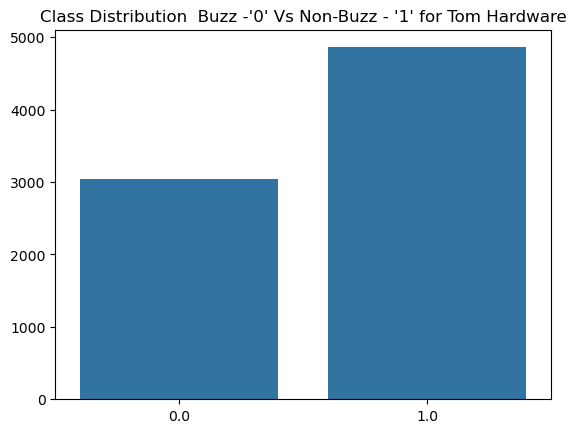

In [19]:
sns.barplot(x = TH['label'].value_counts().index.values,y = TH['label'].value_counts().values)
plt.title("Class Distribution  Buzz -'0' Vs Non-Buzz - '1' for Tom Hardware")

Text(0.5, 1.0, "Class Distribution  Buzz -'0' Vs Non-Buzz - '1' for Twiter")

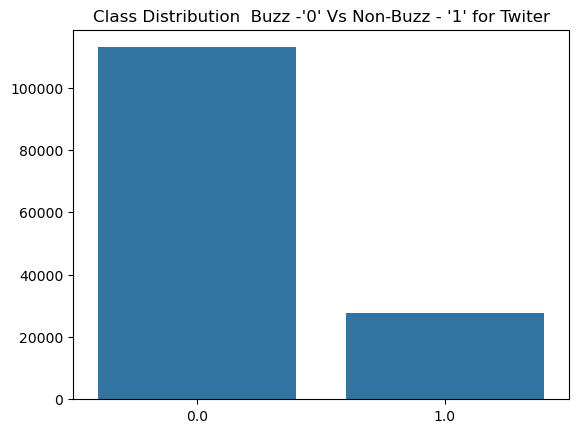

In [12]:
sns.barplot(x = TW['label'].value_counts().index.values,y = TW['label'].value_counts().values)
plt.title("Class Distribution  Buzz -'0' Vs Non-Buzz - '1' for Twiter")

### Dummy clasifier

### Twiter

In [16]:
X = TW.drop(columns=["label"])
y = TW["label"]

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42,stratify=y)

dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred = dummy_majority.predict(X_test)


print("=== Dummy (Most Frequent) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

=== Dummy (Most Frequent) ===
Accuracy: 0.8026082012650132
F1-score: 0.0

Classification Report:

              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89     22587
         1.0       0.00      0.00      0.00      5555

    accuracy                           0.80     28142
   macro avg       0.40      0.50      0.45     28142
weighted avg       0.64      0.80      0.71     28142



### Tom Harware

In [21]:
X = TH.drop(columns=["label"])
y = TH["label"]
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42,stratify=y)
dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred = dummy_majority.predict(X_test)


print("=== Dummy (Most Frequent) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


=== Dummy (Most Frequent) ===
Accuracy: 0.6148007590132827
F1-score: 0.7614571092831962

Classification Report:

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       609
         1.0       0.61      1.00      0.76       972

    accuracy                           0.61      1581
   macro avg       0.31      0.50      0.38      1581
weighted avg       0.38      0.61      0.47      1581

